In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from scipy.ndimage import gaussian_filter

from skimage.transform import resize
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

print("Degradation-Aware NAF-SR Experiment")
print("PyTorch:", torch.__version__)

Degradation-Aware NAF-SR Experiment
PyTorch: 2.5.1+cu121


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Quadro GV100


In [3]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

print("Total pairs:", len(files))

Total pairs: 3200


In [4]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 2560
Validation: 320
Test: 320


In [5]:
def synthetic_degrade(
    gt,
    scale=2
):

    gt = gt.astype(np.float32)

    h, w = gt.shape

    # -------------------------
    # Blur
    # -------------------------

    if np.random.rand() < 0.5:

        sigma = np.random.uniform(
            0.0,
            0.8
        )

        x = gaussian_filter(
            gt,
            sigma=sigma
        )

    else:

        x = gt.copy()


    # -------------------------
    # x2 downsampling
    # -------------------------

    x = resize(
        x,
        (
            h // scale,
            w // scale
        ),
        order=3,
        anti_aliasing=True,
        preserve_range=True
    ).astype(np.float32)


    # -------------------------
    # Multiplicative speckle
    # -------------------------

    if np.random.rand() < 0.75:

        sigma_s = np.random.uniform(
            0.01,
            0.12
        )

        speckle = np.random.normal(
            0,
            sigma_s,
            x.shape
        ).astype(np.float32)

        x = x * (
            1.0 + speckle
        )


    # -------------------------
    # Additive Gaussian
    # -------------------------

    if np.random.rand() < 0.6:

        sigma_g = np.random.uniform(
            0.0,
            0.035
        )

        noise = np.random.normal(
            0,
            sigma_g,
            x.shape
        ).astype(np.float32)

        x = x + noise


    # -------------------------
    # Mild signal variation
    # -------------------------

    if np.random.rand() < 0.25:

        gain = np.random.uniform(
            0.95,
            1.05
        )

        bias = np.random.uniform(
            -0.015,
            0.015
        )

        x = (
            x * gain
            +
            bias
        )


    # IMPORTANT
    # do NOT clip input

    return x.astype(
        np.float32
    )

In [6]:
class KLATrainDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files,
        synthetic_probability=0.20
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files

        self.synthetic_probability = (
            synthetic_probability
        )


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(np.float32)


        if (
            np.random.rand()
            <
            self.synthetic_probability
        ):

            lr = synthetic_degrade(
                gt
            )

        else:

            lr = np.load(
                os.path.join(
                    self.noisy_path,
                    filename
                )
            ).astype(np.float32)


        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)

        return lr, gt


class KLARealDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]

        lr = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(np.float32)

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(np.float32)

        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)

        return lr, gt

In [7]:
BATCH_SIZE = 8

train_dataset = KLATrainDataset(
    GT_PATH,
    NOISY_PATH,
    train_files,
    synthetic_probability=0.20
)

val_dataset = KLARealDataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = KLARealDataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

2560 320 320


In [8]:
class SimpleGate(nn.Module):

    def forward(
        self,
        x
    ):

        a, b = x.chunk(
            2,
            dim=1
        )

        return a * b

In [9]:
class DegradationEstimator(nn.Module):

    def __init__(
        self,
        embedding_dim=32
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                16,
                32,
                3,
                stride=2,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                32,
                64,
                3,
                stride=2,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.AdaptiveAvgPool2d(
                1
            )
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64,
                embedding_dim
            ),

            nn.ReLU(
                inplace=True
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        return self.fc(
            x
        )

In [10]:
class ConditionalNAFBlock(nn.Module):

    def __init__(
        self,
        channels,
        degradation_dim=32,
        expansion=2
    ):

        super().__init__()

        hidden = (
            channels
            *
            expansion
        )


        self.norm1 = nn.GroupNorm(
            1,
            channels
        )


        self.conv1 = nn.Conv2d(
            channels,
            hidden * 2,
            1
        )


        self.dwconv = nn.Conv2d(
            hidden * 2,
            hidden * 2,
            3,
            padding=1,
            groups=hidden * 2
        )


        self.gate = SimpleGate()


        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                hidden,
                hidden,
                1
            )
        )


        self.conv2 = nn.Conv2d(
            hidden,
            channels,
            1
        )


        self.condition = nn.Linear(
            degradation_dim,
            channels * 2
        )


        self.norm2 = nn.GroupNorm(
            1,
            channels
        )


        self.ffn1 = nn.Conv2d(
            channels,
            channels * 2,
            1
        )


        self.ffn_gate = SimpleGate()


        self.ffn2 = nn.Conv2d(
            channels,
            channels,
            1
        )


        self.beta = nn.Parameter(
            torch.zeros(
                1,
                channels,
                1,
                1
            )
        )


        self.gamma = nn.Parameter(
            torch.zeros(
                1,
                channels,
                1,
                1
            )
        )


    def forward(
        self,
        x,
        degradation_embedding
    ):

        # --------------------------------
        # Degradation conditioning
        # --------------------------------

        condition = self.condition(
            degradation_embedding
        )

        scale, bias = condition.chunk(
            2,
            dim=1
        )

        scale = scale.unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        bias = bias.unsqueeze(
            -1
        ).unsqueeze(
            -1
        )


        # --------------------------------
        # Main NAF branch
        # --------------------------------

        y = self.norm1(
            x
        )

        y = (
            y
            *
            (1 + 0.1 * scale)
            +
            0.1 * bias
        )


        y = self.conv1(
            y
        )

        y = self.dwconv(
            y
        )

        y = self.gate(
            y
        )


        attention = (
            self.channel_attention(
                y
            )
        )


        y = (
            y
            *
            attention
        )


        y = self.conv2(
            y
        )


        x = (
            x
            +
            self.beta * y
        )


        # --------------------------------
        # FFN branch
        # --------------------------------

        y = self.norm2(
            x
        )

        y = self.ffn1(
            y
        )

        y = self.ffn_gate(
            y
        )

        y = self.ffn2(
            y
        )


        return (
            x
            +
            self.gamma * y
        )

In [11]:
class DANAFSR(nn.Module):

    def __init__(
        self,
        channels=48,
        num_blocks=8,
        scale=2,
        degradation_dim=32
    ):

        super().__init__()


        self.degradation_estimator = (
            DegradationEstimator(
                degradation_dim
            )
        )


        self.head = nn.Conv2d(
            1,
            channels,
            3,
            padding=1
        )


        self.blocks = nn.ModuleList([
            ConditionalNAFBlock(
                channels,
                degradation_dim
            )
            for _ in range(
                num_blocks
            )
        ])


        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )


        self.up = nn.Sequential(

            nn.Conv2d(
                channels,
                channels
                *
                scale
                *
                scale,
                3,
                padding=1
            ),

            nn.PixelShuffle(
                scale
            ),

            nn.Conv2d(
                channels,
                1,
                3,
                padding=1
            )
        )


    def forward(
        self,
        x
    ):

        degradation_embedding = (
            self.degradation_estimator(
                x
            )
        )


        features = self.head(
            x
        )


        residual = features


        for block in self.blocks:

            features = block(
                features,
                degradation_embedding
            )


        features = self.body_conv(
            features
        )


        features = (
            features
            +
            residual
        )


        output = self.up(
            features
        )


        return output

In [12]:
model = DANAFSR(
    channels=48,
    num_blocks=8,
    scale=2,
    degradation_dim=32
).to(
    device
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(model)

print(
    "\nTotal parameters:",
    total_params
)

DANAFSR(
  (degradation_estimator): DegradationEstimator(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU(inplace=True)
      (6): AdaptiveAvgPool2d(output_size=1)
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=64, out_features=32, bias=True)
      (2): ReLU(inplace=True)
    )
  )
  (head): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): ModuleList(
    (0-7): 8 x ConditionalNAFBlock(
      (norm1): GroupNorm(1, 48, eps=1e-05, affine=True)
      (conv1): Conv2d(48, 192, kernel_size=(1, 1), stride=(1, 1))
      (dwconv): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=192)
      (gate): SimpleGat

In [13]:
dummy = torch.randn(
    2,
    1,
    128,
    128
).to(device)

with torch.no_grad():

    out = model(
        dummy
    )

print(
    "Input:",
    dummy.shape
)

print(
    "Output:",
    out.shape
)

Input: torch.Size([2, 1, 128, 128])
Output: torch.Size([2, 1, 256, 256])


In [14]:
def gaussian_window(
    window_size=11,
    sigma=1.5,
    channels=1,
    device="cpu"
):

    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    )

    coords -= (
        window_size // 2
    )

    g = torch.exp(
        -(coords ** 2)
        /
        (
            2 * sigma ** 2
        )
    )

    g /= g.sum()

    window = (
        g[:, None]
        *
        g[None, :]
    )

    return window.expand(
        channels,
        1,
        window_size,
        window_size
    )

In [15]:
def differentiable_ssim(
    x,
    y,
    window_size=11
):

    channels = x.shape[1]

    window = gaussian_window(
        window_size,
        1.5,
        channels,
        x.device
    )


    mu_x = F.conv2d(
        x,
        window,
        padding=window_size//2,
        groups=channels
    )


    mu_y = F.conv2d(
        y,
        window,
        padding=window_size//2,
        groups=channels
    )


    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y


    sigma_x = (
        F.conv2d(
            x*x,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_x2
    )


    sigma_y = (
        F.conv2d(
            y*y,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_y2
    )


    sigma_xy = (
        F.conv2d(
            x*y,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_xy
    )


    C1 = 0.01 ** 2
    C2 = 0.03 ** 2


    ssim_map = (
        (
            2 * mu_xy + C1
        )
        *
        (
            2 * sigma_xy + C2
        )
    ) / (
        (
            mu_x2
            +
            mu_y2
            +
            C1
        )
        *
        (
            sigma_x
            +
            sigma_y
            +
            C2
        )
        +
        1e-8
    )


    return ssim_map.mean()

In [16]:
def restoration_loss(
    output,
    target
):

    l1 = F.l1_loss(
        output,
        target
    )


    ssim = differentiable_ssim(
        output,
        target
    )


    ssim_loss = (
        1.0
        -
        ssim
    )


    loss = (
        l1
        +
        0.10
        *
        ssim_loss
    )


    return (
        loss,
        l1,
        ssim_loss
    )

In [17]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

EPOCHS = 30

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

print(
    "Optimizer ready"
)

Optimizer ready


In [18]:
MODEL_DIR = "../models/danafsr"
RESULT_DIR = "../results/danafsr"

RESTORED_DIR = (
    "../results/danafsr/restored"
)

for path in [
    MODEL_DIR,
    RESULT_DIR,
    RESTORED_DIR
]:

    os.makedirs(
        path,
        exist_ok=True
    )

print(
    "Directories ready"
)

Directories ready


In [19]:
def evaluate_validation(
    model,
    loader
):

    model.eval()

    psnr_values = []
    ssim_values = []


    with torch.no_grad():

        for lr, gt in loader:

            lr = lr.to(
                device,
                non_blocking=True
            )

            output = model(
                lr
            )

            output = torch.clamp(
                output,
                0,
                1
            )


            output_np = (
                output
                .cpu()
                .numpy()
            )


            gt_np = (
                gt.numpy()
            )


            for i in range(
                output_np.shape[0]
            ):

                pred = (
                    output_np[
                        i,
                        0
                    ]
                )

                target = (
                    gt_np[
                        i,
                        0
                    ]
                )


                psnr_values.append(
                    peak_signal_noise_ratio(
                        target,
                        pred,
                        data_range=1.0
                    )
                )


                ssim_values.append(
                    structural_similarity(
                        target,
                        pred,
                        data_range=1.0
                    )
                )


    return (
        np.mean(psnr_values),
        np.mean(ssim_values)
    )

In [20]:
best_psnr = -1

train_history = []
val_psnr_history = []
val_ssim_history = []


for epoch in range(
    EPOCHS
):


    # =====================
    # TRAIN
    # =====================

    model.train()

    running_loss = 0.0


    for lr, gt in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):


        lr = lr.to(
            device,
            non_blocking=True
        )


        gt = gt.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        output = model(
            lr
        )


        (
            loss,
            _,
            _
        ) = restoration_loss(
            output,
            gt
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()


        running_loss += (
            loss.item()
        )


    train_loss = (
        running_loss
        /
        len(train_loader)
    )


    scheduler.step()


    # =====================
    # VALIDATION
    # =====================

    val_psnr, val_ssim = (
        evaluate_validation(
            model,
            val_loader
        )
    )


    train_history.append(
        train_loss
    )


    val_psnr_history.append(
        val_psnr
    )


    val_ssim_history.append(
        val_ssim
    )


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.6f} | "
        f"PSNR: {val_psnr:.4f} dB | "
        f"SSIM: {val_ssim:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.7f}"
    )


    # =====================
    # BEST CHECKPOINT
    # =====================

    if val_psnr > best_psnr:

        best_psnr = val_psnr


        checkpoint = {

            "epoch":
                epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "val_psnr":
                val_psnr,

            "val_ssim":
                val_ssim,

            "config": {

                "channels": 48,

                "blocks": 8,

                "scale": 2,

                "degradation_dim": 32,

                "synthetic_probability": 0.20
            }
        }


        torch.save(
            checkpoint,
            "../models/danafsr/"
            "danafsr_best.pth"
        )


        print(
            "★ Best model saved"
        )

Epoch 1/30: 100%|██████████| 320/320 [01:23<00:00,  3.81it/s]


Epoch [01/30] Loss: 0.089693 | PSNR: 24.5651 dB | SSIM: 0.6287 | LR: 0.0001995
★ Best model saved


Epoch 3/30: 100%|██████████| 320/320 [01:29<00:00,  3.57it/s]


Epoch [03/30] Loss: 0.066006 | PSNR: 26.3898 dB | SSIM: 0.6993 | LR: 0.0001951
★ Best model saved


Epoch 4/30: 100%|██████████| 320/320 [01:18<00:00,  4.09it/s]


...

Epoch [28/30] Loss: 0.055159 | PSNR: 27.5523 dB | SSIM: 0.7487 | LR: 0.0000032


Epoch 29/30: 100%|██████████| 320/320 [01:24<00:00,  3.78it/s]


Epoch [29/30] Loss: 0.055171 | PSNR: 27.5661 dB | SSIM: 0.7481 | LR: 0.0000015


Epoch 30/30: 100%|██████████| 320/320 [01:24<00:00,  3.80it/s]


Epoch [30/30] Loss: 0.055416 | PSNR: 27.5685 dB | SSIM: 0.7483 | LR: 0.0000010
★ Best model saved


In [21]:
history_df = pd.DataFrame({
    "Epoch": range(1, len(train_history) + 1),
    "Train_Loss": train_history,
    "Val_PSNR": val_psnr_history,
    "Val_SSIM": val_ssim_history
})

history_df.to_csv(
    "../results/danafsr/training_history.csv",
    index=False
)

history_df.tail()

,Epoch,Train_Loss,Val_PSNR,Val_SSIM
25,26,0.055163,27.554178,0.748336
26,27,0.055334,27.543946,0.748301
27,28,0.055159,27.552265,0.748660
28,29,0.055171,27.566129,0.748069
29,30,0.055416,27.568501,0.748300


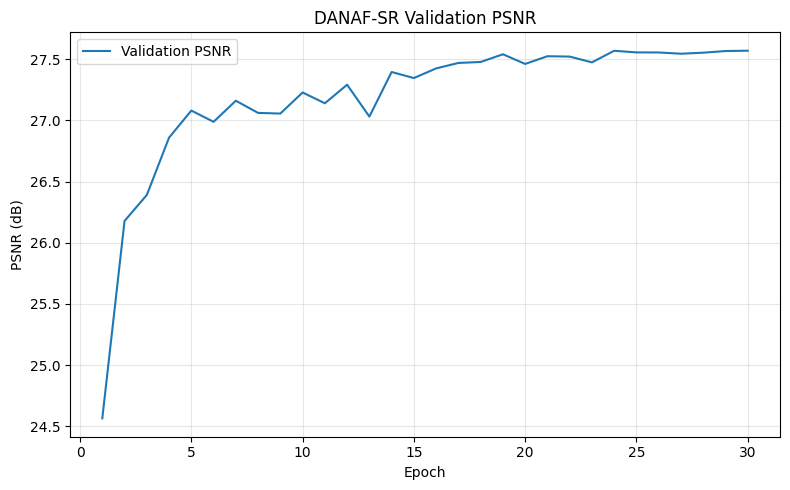

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(val_psnr_history)+1),
    val_psnr_history,
    label="Validation PSNR"
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("DANAF-SR Validation PSNR")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/danafsr/validation_psnr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

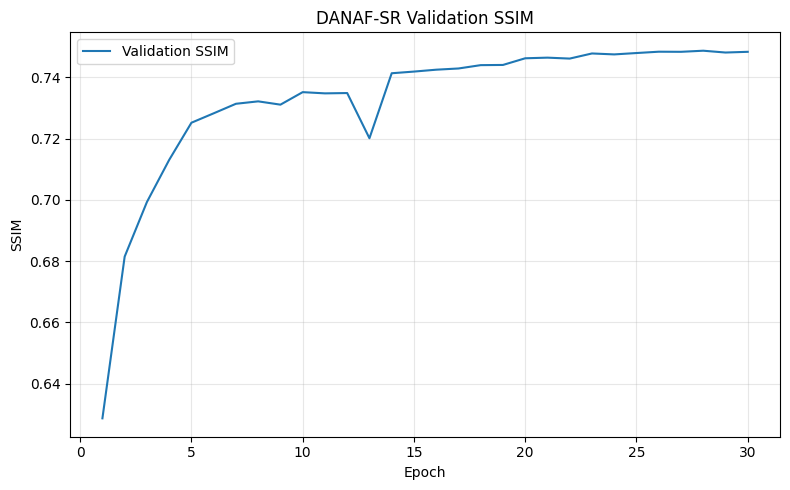

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(val_ssim_history)+1),
    val_ssim_history,
    label="Validation SSIM"
)

plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("DANAF-SR Validation SSIM")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/danafsr/validation_ssim_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
best_epoch = int(
    np.argmax(val_psnr_history)
) + 1

best_val_psnr = float(
    np.max(val_psnr_history)
)

best_val_ssim_at_psnr = float(
    val_ssim_history[best_epoch - 1]
)

with open(
    "../results/danafsr/metrics.txt",
    "w"
) as f:

    f.write("DANAF-SR Experiment\n")
    f.write("===================\n\n")

    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best Validation PSNR: {best_val_psnr:.6f} dB\n")
    f.write(
        f"Validation SSIM at Best PSNR: "
        f"{best_val_ssim_at_psnr:.6f}\n"
    )

    f.write("\nConfig:\n")
    f.write("Channels: 48\n")
    f.write("Blocks: 8\n")
    f.write("Scale: 2\n")
    f.write("Degradation embedding: 32\n")
    f.write("Synthetic probability: 0.20\n")

print("DANAF-SR results saved.")

DANAF-SR results saved.
